Friendship ended with pytorch diffrax is my best friend now

In [1]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import optax as opx
import matplotlib.pyplot as plt 
import jax.random as jr
import pysindy as ps 

jax.config.update("jax_enable_x64", True) # enable 64 float precision for stiff problems

In [3]:
from pysr import PySRRegressor

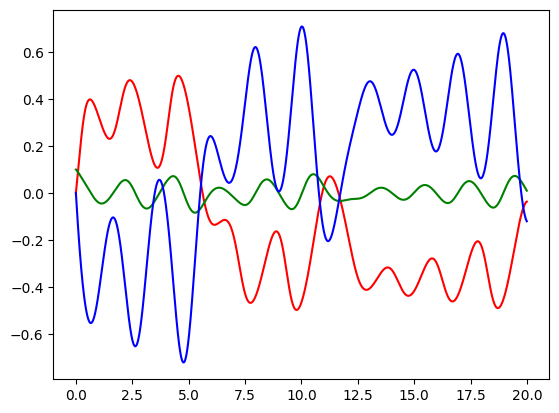

In [4]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, args):
    alpha, beta, gamma, a, c = args 
    x,y,z = xyz 
    return jnp.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

T_MAX = 20

term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()
y0 = jnp.array((0.0001, 0.1, 0))
saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.01))

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

plt.plot(sol.ts, sol.ys[:, 0], color='r')
plt.plot(sol.ts, sol.ys[:, 1], color='g')
plt.plot(sol.ts, sol.ys[:, 2], color='b')


In [227]:
T_MAX = 30
@jax.jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0.0001, 0.1, 0))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.1))

    # training set
    sol_train = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_train = sol_train.ys[::5]
    t_train = sol_train.ts[::5]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX+T_MAX*0.5, 0.1))
    y0 = jnp.array((0.0001, 0.1, 0.0001))
    sol_val = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX+T_MAX*0.5, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_val = sol_val.ys[::2]
    t_val = sol_val.ts[::2]

    return x_train, t_train, x_val, t_val, sol_train, sol_val

In [228]:
x_train, t_train, x_val, t_val, sol_train, sol_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


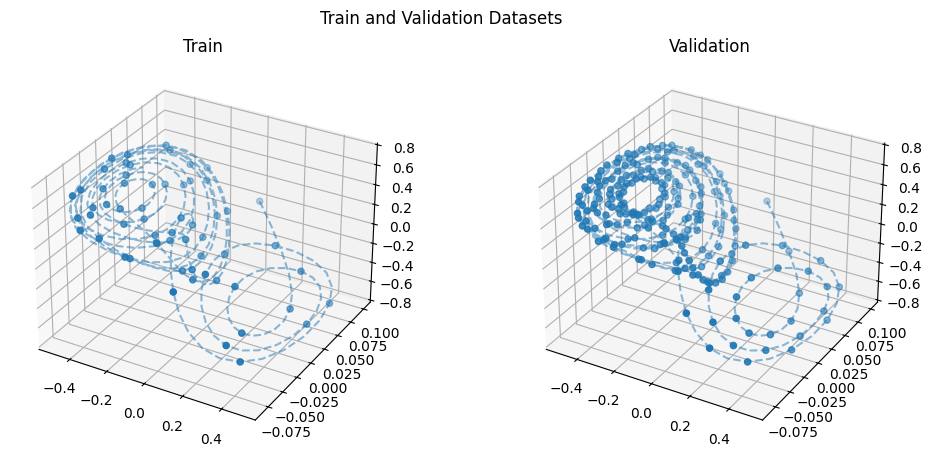

In [229]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(projection='3d'))

axes[0].scatter(x_train[:, 0],x_train[:, 1],x_train[:, 2])
axes[1].scatter(x_val[:, 0],x_val[:, 1],x_val[:, 2])

axes[0].plot(sol_train.ys[:, 0],sol_train.ys[:, 1],sol_train.ys[:, 2], alpha=0.5, linestyle='--')
axes[1].plot(sol_val.ys[:, 0],sol_val.ys[:, 1],sol_val.ys[:, 2], alpha=0.5, linestyle='--')

axes[0].set_title("Train")
axes[1].set_title("Validation")

plt.suptitle("Train and Validation Datasets")

plt.show()

In [8]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

In [9]:
class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        t = jnp.clip(t, self.t_obs[0], self.t_obs[-1])
        idx = jnp.searchsorted(self.t_obs, t, side="left")
        idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

        t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
        y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1.0 - w) * y0 + w * y1

In [10]:
class ChuaUdeX_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array
    obs_fun: LinearInterpolator

    def __init__(self, alpha, beta, gamma, K, obs_fun, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=128,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)
        self.obs_fun = obs_fun

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state):
        y_hat = self.obs_fun(t)
        return y_hat - state

    def __call__(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state)


In [11]:
class ChuaUdeXYZ_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array
    obs_fun: LinearInterpolator

    def __init__(self, alpha, beta, gamma, K, obs_fun, key):
        self.net = eqx.nn.MLP(
            in_size=3,
            out_size=3,
            width_size=128,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)
        self.obs_fun = obs_fun

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        return jnp.array(
            [
                self.net(state)[0], 0, 0
            ]
        )
    
    def error(self, t, state):
        y_hat = self.obs_fun(t)
        return y_hat - state

    def __call__(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state)


In [12]:
def solve_ude_light(model, y0, ts):
    term = dfx.ODETerm(model)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    stepper = dfx.PIDController(rtol=1e-6, atol=1e-8)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        saveat=saveat,
        stepsize_controller=stepper
    )
    return sol.ys



In [13]:
@eqx.filter_value_and_grad
def loss_fn(model, x0, y_true, ts):
    # calculate loss
    pred = solve_ude_light(model, x0, ts)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, x0, x_true, ts, optimizer):
    # one train step on the dataset
    loss, grads = loss_fn(model, x0, x_true, ts)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [15]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)
ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.3, 0.1, 0.1],linear_interp_jit, key)

# Train UDE PEM 

lr = 0.001
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    ude_pem, opt_state, loss = train_step(ude_pem, opt_state, x_train[0], x_train, t_train, optimizer)

    val_loss = None

    train_losses_pem.append(loss)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn(ude_pem, x_val[0], x_val, t_val)[0]
        val_losses_pem.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")


0	3.6327e-02	5.4364e-02
1	4.7531e-02	---
2	3.5902e-02	---
3	3.6624e-02	---
4	3.8706e-02	---
5	3.7460e-02	---
6	3.4961e-02	---
7	3.3508e-02	---
8	3.3935e-02	---
9	3.4043e-02	---
10	3.3190e-02	---
11	3.2262e-02	---
12	3.1667e-02	---
13	3.1360e-02	---
14	3.1122e-02	---
15	3.0782e-02	---
16	3.0329e-02	---
17	2.9840e-02	---
18	2.9380e-02	---
19	2.8987e-02	---
20	2.8628e-02	---
21	2.8268e-02	---
22	2.7875e-02	---
23	2.7428e-02	---
24	2.6965e-02	---
25	2.6539e-02	---
26	2.6136e-02	---
27	2.5710e-02	---
28	2.5238e-02	---
29	2.4767e-02	---
30	2.4347e-02	---
31	2.3915e-02	---
32	2.3427e-02	---
33	2.2942e-02	---
34	2.2477e-02	---
35	2.1954e-02	---
36	2.1397e-02	---
37	2.0854e-02	---
38	2.0258e-02	---
39	1.9642e-02	---
40	1.9069e-02	---
41	1.8479e-02	---
42	1.8005e-02	---
43	1.7795e-02	---
44	1.7023e-02	---
45	1.6209e-02	---
46	1.5368e-02	---
47	1.4409e-02	---
48	1.3663e-02	---
49	1.2575e-02	---
50	1.2322e-02	---
51	1.2004e-02	---
52	1.0393e-02	---
53	1.1637e-02	---
54	1.1672e-02	---
55	9.6845e-03

In [19]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)
ude_pem_XYZ = ChuaUdeXYZ_PEM(ALPHA, BETA, GAMMA, [0.3, 0.1, 0.1],linear_interp_jit, key)

# Train UDE PEM 

lr = 0.001
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem_XYZ, eqx.is_inexact_array))

train_losses_pem_XYZ = []
val_losses_pem_XYZ = []

for i in range(0, n_epochs):
    ude_pem_XYZ, opt_state, loss = train_step(ude_pem_XYZ, opt_state, x_train[0], x_train, t_train, optimizer)

    val_loss = None

    train_losses_pem_XYZ.append(loss)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn(ude_pem_XYZ, x_val[0], x_val, t_val)[0]
        val_losses_pem_XYZ.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")


0	3.6327e-02	3.5136e-02
1	3.5724e-02	---
2	3.5362e-02	---
3	3.4938e-02	---
4	3.4462e-02	---
5	3.4001e-02	---
6	3.3544e-02	---
7	3.3074e-02	---
8	3.2575e-02	---
9	3.2051e-02	---
10	3.1503e-02	---
11	3.0964e-02	---
12	3.0433e-02	---
13	2.9937e-02	---
14	2.9432e-02	---
15	2.8897e-02	---
16	2.8329e-02	---
17	2.7762e-02	---
18	2.7194e-02	---
19	2.6552e-02	---
20	2.5807e-02	---
21	2.5017e-02	---
22	2.4226e-02	---
23	2.3442e-02	---
24	2.2824e-02	---
25	2.2346e-02	---
26	2.3434e-02	---
27	2.3887e-02	---
28	2.2749e-02	---
29	2.0509e-02	---
30	2.1669e-02	---
31	2.0755e-02	---
32	1.9633e-02	---
33	1.9808e-02	---
34	1.9718e-02	---
35	1.9159e-02	---
36	1.8627e-02	---
37	1.8329e-02	---
38	1.8095e-02	---
39	1.7687e-02	---
40	1.7169e-02	---
41	1.6785e-02	---
42	1.6506e-02	---
43	1.6102e-02	---
44	1.5553e-02	---
45	1.5039e-02	---
46	1.4643e-02	---
47	1.4211e-02	---
48	1.3577e-02	---
49	1.2912e-02	---
50	1.2339e-02	---
51	1.1696e-02	---
52	1.1144e-02	---
53	1.0435e-02	---
54	9.8586e-03	---
55	9.2413e-03

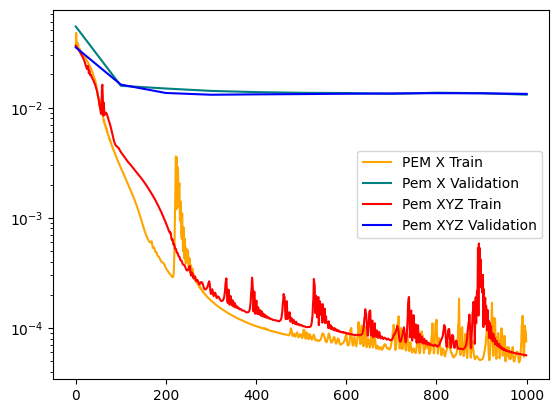

In [20]:
plt.semilogy(range(0, len(train_losses_pem)), train_losses_pem, color='orange', label="PEM X Train")
plt.semilogy(100*jnp.array(range(len(val_losses_pem))), val_losses_pem, color='teal', label="Pem X Validation")

plt.semilogy(range(0, len(train_losses_pem)), train_losses_pem_XYZ, color='red', label="Pem XYZ Train")
plt.semilogy(100*jnp.array(range(len(val_losses_pem))), val_losses_pem_XYZ, color='blue', label="Pem XYZ Validation")

plt.legend()
plt.show()

In [21]:
# save model
eqx.tree_serialise_leaves("./models_weights/31_4_ude_pem_x__jax.eqx", ude_pem)
eqx.tree_serialise_leaves("./models_weights/31_4_ude_pem_xyz_jax.eqx", ude_pem_XYZ)


In [136]:
# load models
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, (0.3, 0.1, 0.3), linear_interp_jit, key)
ude_pem_XYZ = ChuaUdeXYZ_PEM(ALPHA, BETA, GAMMA, (0.3, 0.1, 0.3), linear_interp_jit, key)

ude_pem = eqx.tree_deserialise_leaves("./models_weights/31_4_ude_pem_x__jax.eqx", ude_pem)
ude_pem_XYZ = eqx.tree_deserialise_leaves("./models_weights/31_4_ude_pem_xyz_jax.eqx", ude_pem_XYZ)


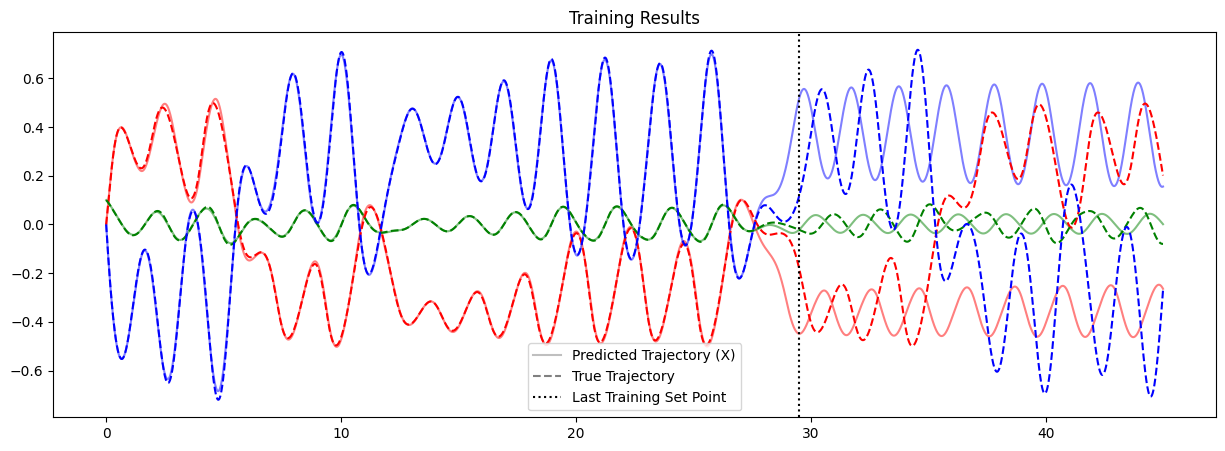

In [137]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 45

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
fig, axes = plt.subplots(figsize=(15, 5))

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper).ys

plt.plot(t_eval, traj_final[:, 0], color='r', alpha=0.5)
plt.plot(t_eval, traj_final[:, 1], color='g', alpha=0.5)
plt.plot(t_eval, traj_final[:, 2], color='b', alpha=0.5)

plt.plot(t_eval, traj_true[:, 0], color='r', linestyle='--')
plt.plot(t_eval, traj_true[:, 1], color='g', linestyle='--')
plt.plot(t_eval, traj_true[:, 2], color='b', linestyle='--')

plt.plot([], [], color="gray", alpha=0.5, label="Predicted Trajectory (X)")
plt.plot([], [], color="gray", linestyle="--", label="True Trajectory")
plt.axvline(t_train[-1], color="k", linestyle=":", label="Last Training Set Point")

plt.legend()
plt.title("Training Results")
plt.show()

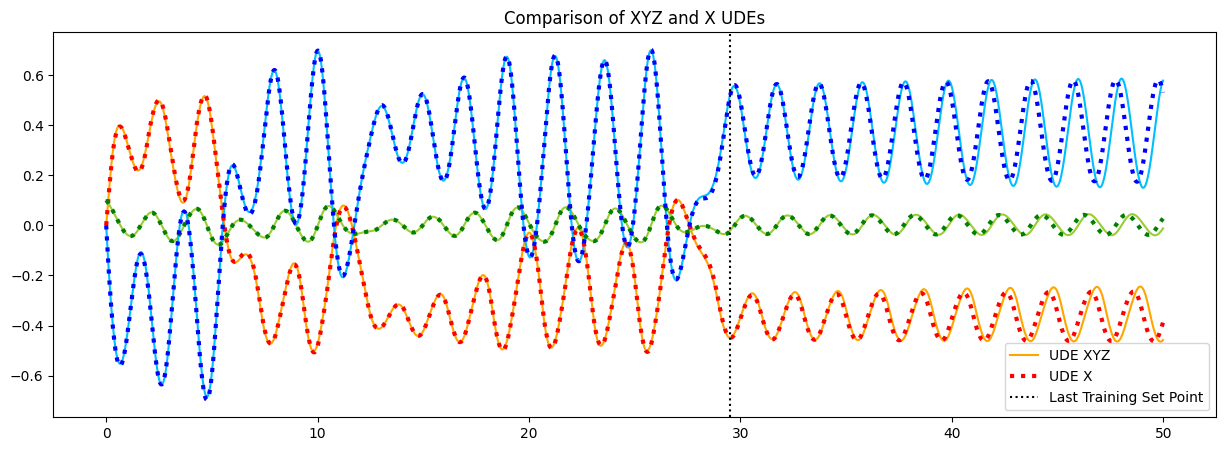

In [176]:
term_ude_x = dfx.ODETerm(ude_pem)
term_ude_xyz = dfx.ODETerm(ude_pem_XYZ)

T_MAX = 50

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
fig, axes = plt.subplots(figsize=(15, 5))

sol = dfx.diffeqsolve(term_ude_x, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude_xyz, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper).ys
plt.plot(t_eval, traj_true[:, 0], color='orange',label="UDE XYZ")
plt.plot(t_eval, traj_true[:, 1], color='yellowgreen')
plt.plot(t_eval, traj_true[:, 2], color='deepskyblue')

plt.plot(t_eval, traj_final[:, 0], color='r', linestyle=':', label="UDE X", linewidth=3)
plt.plot(t_eval, traj_final[:, 1], color='g',linestyle=':', linewidth=3)
plt.plot(t_eval, traj_final[:, 2], color='b',linestyle=':', linewidth=3)


plt.axvline(t_train[-1], color="k", linestyle=":", label="Last Training Set Point")

plt.legend()

plt.title("Comparison of XYZ and X UDEs")
plt.show()

They are wrong in the exactly same way; no significant difference between the two models

We will use X for simplicity

In [220]:
# plot learned network
y_hats = []
ys = []
for x in (x_space:=jnp.arange(-0.5, 0.5, 0.01)):
    print(y_hat)
    y_hat = ude_pem.net(x)
    y_hats.append(y_hat)
    ys.append(A*x**3 + C*x)


0.013413757139191164
-0.037827830379458006
-0.03462929641731367
-0.03072800717274254
-0.026629873924295923
-0.022837322329698612
-0.019822318200028218
-0.017024291474252128
-0.014195404680214976
-0.011340170633100293
-0.008582547883207265
-0.00590598757946511
-0.0031059741495735524
-0.00036287491771997283
0.002496216687719018
0.0049862156447788375
0.0072120276315195755
0.009446702610865712
0.011624974688219745
0.012704032563667271
0.013392561348449
0.013895083381641856
0.014135577737308997
0.014276985797436914
0.01433643795995248
0.01436211738297924
0.014364641989105552
0.014329781023724135
0.014262656063309481
0.014129194974367728
0.013959736414536216
0.01355403183713308
0.013042156027346274
0.012484878228660228
0.011925016953656662
0.011387742326064368
0.010852029068085418
0.010316315810106466
0.009780602552127515
0.009244889294148562
0.008709176036169608
0.008173462778190657
0.007637749520211704
0.007111531015390764
0.006577431334678719
0.006018698669041834
0.005340968032472316
0.00

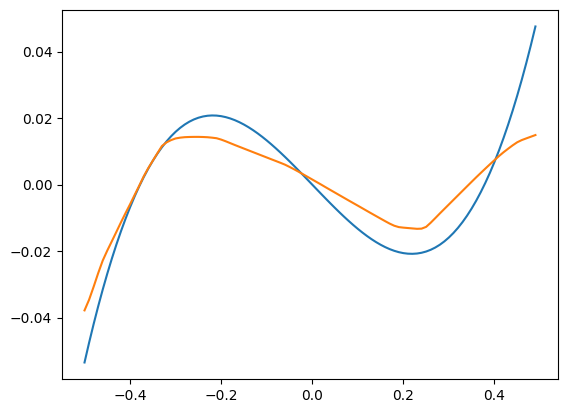

In [221]:
plt.plot(x_space, ys)
plt.plot(x_space, y_hats)


In [222]:
# plot learned network
y_hats = []
ys = []
for x in (x_space:=jnp.arange(-2, 2, 0.01)):
    print(y_hat)
    y_hat = ude_pem.net(x)
    y_hats.append(y_hat)
    ys.append(A*x**3 + C*x)


0.014919101987236788
-0.15095179363439187
-0.1503171180179026
-0.1496824424014134
-0.14904776678492412
-0.1484138430839353
-0.14777993789763708
-0.14714603271133883
-0.14651212752504064
-0.14587788989878667
-0.14524053825341576
-0.1446031866080449
-0.143965834962674
-0.14332848331730316
-0.1426911316719323
-0.1420537800265614
-0.14141642838119053
-0.14078088503442748
-0.14014617290962067
-0.13951146078481383
-0.138876748660007
-0.13824203653520017
-0.13760732441039333
-0.13697261228558652
-0.13633790016077968
-0.13570318803597287
-0.13506847591116602
-0.1344338663078814
-0.13380057656814495
-0.13316728682840853
-0.1325339970886721
-0.13190070734893566
-0.13126741760919922
-0.13063334140075147
-0.12999612061634103
-0.1293588998319306
-0.12871991362772478
-0.12807439357671255
-0.12743792443609323
-0.1268003143325112
-0.12616274495202978
-0.12552723022064857
-0.1248947078032976
-0.12425121858702783
-0.12360772937075801
-0.1229642401544882
-0.12232075093821838
-0.12167726172194858
-0.12102

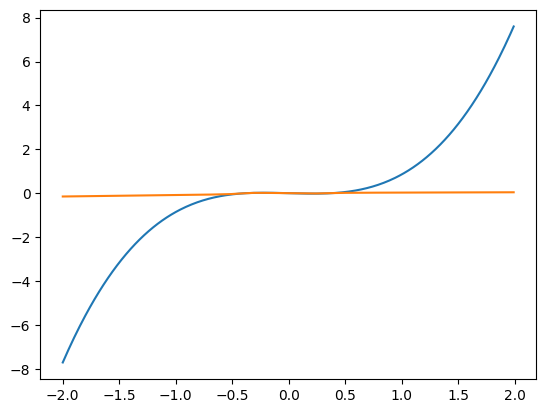

In [223]:
plt.plot(x_space, ys)
plt.plot(x_space, y_hats)


In [213]:
class ChuaUdeX_PEM_nozeroing(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array
    obs_fun: LinearInterpolator

    def __init__(self, alpha, beta, gamma, K, obs_fun, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=128,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)
        self.obs_fun = obs_fun

    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state):
        y_hat = self.obs_fun(t)
        return y_hat - state

    def __call__(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state)


In [215]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)
ude_pem_nozeroing = ChuaUdeX_PEM_nozeroing(ALPHA, BETA, GAMMA, [0.3, 0.1, 0.1],linear_interp_jit, key)

# Train UDE PEM 

lr = 0.001
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem_nozeroing, eqx.is_inexact_array))

train_losses_pem_nozeroing = []
val_losses_pem_nozeroing = []

for i in range(0, n_epochs):
    ude_pem_nozeroing, opt_state, loss = train_step(ude_pem_nozeroing, opt_state, x_train[0], x_train, t_train, optimizer)

    val_loss = None

    train_losses_pem_nozeroing.append(loss)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn(ude_pem_nozeroing, x_val[0], x_val, t_val)[0]
        val_losses_pem_nozeroing.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")


0	2.8813e+00	1.0312e-01
1	1.1490e-01	---
2	3.6345e-01	---
3	2.8295e-01	---
4	1.5224e-01	---
5	9.1327e-02	---
6	6.4552e-02	---
7	5.5966e-02	---
8	5.8780e-02	---
9	6.5251e-02	---
10	6.9592e-02	---
11	7.1153e-02	---
12	6.9910e-02	---
13	6.6453e-02	---
14	6.1092e-02	---
15	5.5048e-02	---
16	4.9355e-02	---
17	4.5132e-02	---
18	4.2497e-02	---
19	4.1424e-02	---
20	4.1244e-02	---
21	4.0990e-02	---
22	3.9773e-02	---
23	3.7522e-02	---
24	3.5133e-02	---
25	3.4003e-02	---
26	3.4524e-02	---
27	3.4875e-02	---
28	3.3165e-02	---
29	3.1164e-02	---
30	3.1134e-02	---
31	3.1936e-02	---
32	3.1334e-02	---
33	2.9893e-02	---
34	3.0290e-02	---
35	3.0843e-02	---
36	2.9541e-02	---
37	2.9302e-02	---
38	2.9716e-02	---
39	2.9061e-02	---
40	2.8178e-02	---
41	2.8250e-02	---
42	2.8111e-02	---
43	2.7305e-02	---
44	2.6954e-02	---
45	2.6977e-02	---
46	2.6625e-02	---
47	2.6072e-02	---
48	2.5882e-02	---
49	2.5807e-02	---
50	2.5423e-02	---
51	2.5014e-02	---
52	2.4848e-02	---
53	2.4649e-02	---
54	2.4242e-02	---
55	2.3877e-02

In [218]:
# plot learned network
y_hats = []
ys = []
for x in (x_space:=jnp.arange(-0.5, 0.5, 0.01)):
    print(y_hat)
    y_hat = ude_pem_nozeroing.net(x)
    y_hats.append(y_hat)
    ys.append(A*x**3 + C*x)

0.04196068153884299
-0.02713906724257189
-0.025001274219256853
-0.022858375091824885
-0.02072206890550041
-0.01859477600597633
-0.016556210546399195
-0.014488024062012984
-0.012424685488583252
-0.010392765325401355
-0.008277863715242272
-0.006080724417936377
-0.0038950875095284596
-0.001593952797093151
0.0007841490551011611
0.0031604208171027576
0.0055757113429503215
0.007862631604264272
0.009507894781108386
0.010663631305911195
0.01153590194732735
0.011964376481902225
0.01211987417002034
0.012163302875224637
0.012113269023500878
0.011952450996565785
0.011780775666254288
0.011605912286826156
0.01142396753796654
0.011238994562808566
0.011000173919975306
0.010734805643063991
0.010312647151341621
0.009894096721606304
0.00949147250356652
0.009113120607506353
0.008757808501884384
0.008399067542773756
0.00803986437346648
0.007715076371591682
0.0073895593245294384
0.007064042277467188
0.006736185762796425
0.006372013991300593
0.005980401833600532
0.005477490116481767
0.00495032254813587
0.004

Text(0.5, 0.98, 'Learned UDE vs Real Unknown Term')

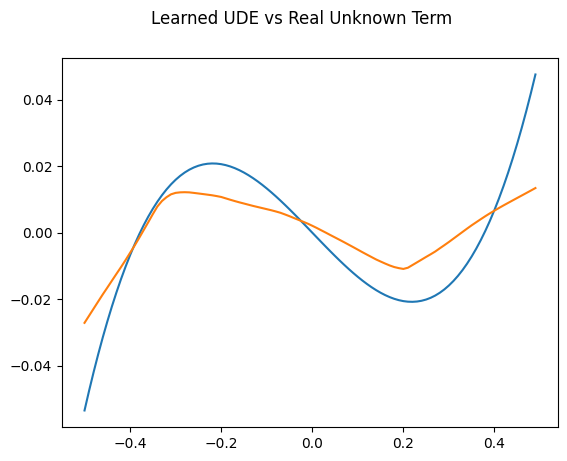

In [219]:
plt.plot(x_space, ys)
plt.plot(x_space, y_hats)

plt.suptitle("Learned UDE vs Real Unknown Term")

## Symbolic Regression
Let's use SINDy again!

In [93]:
# baseline: only training data

In [94]:
x_train_reduced = x_train[::]
t_train_reduced = t_train[::]

t_train_reduced

Array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
        5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
       11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
       16.5, 17. , 17.5, 18. , 18.5, 19. , 19.5, 20. , 20.5, 21. , 21.5,
       22. , 22.5, 23. , 23.5, 24. , 24.5, 25. , 25.5, 26. , 26.5, 27. ,
       27.5, 28. , 28.5, 29. , 29.5], dtype=float64)

In [126]:
sindy_baseline = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.STLSQ(max_iter=1000000, threshold=0.35, verbose=True)
)

sindy_baseline.fit(x_train_reduced, t_train_reduced, feature_names=['x', 'y', 'z'])


sindy_baseline.print()

 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 5.7133e+00 ... 3.5680e+00 ...         11 ... 9.2813e+00
         1 ... 4.0527e+00 ... 3.9853e+00 ...          9 ... 8.0380e+00
         2 ... 3.7200e+00 ... 4.0105e+00 ...          9 ... 7.7305e+00
(x)' =  6.271 y +  0.552 z^3
(y)' =  0.659 x + -0.739 y +  0.666 z
(z)' = -12.857 y + -0.786 x y + -0.073 x^3 +  9.011 y z^2


In [130]:
# Train with PEM
X_dot = jnp.zeros_like(x_train_reduced)

for i, (t, x) in enumerate(zip(t_train_reduced, x_train_reduced)):
    X_dot = X_dot.at[i, :].set(ude_pem(t, x, None))

sindy_ude = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.STLSQ(max_iter=1000000, threshold=0.3, verbose=True)
)

sindy_ude.fit(x_train_reduced, t_train_reduced, feature_names=['x', 'y', 'z'], x_dot=X_dot )

sindy_ude.print()

 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 4.2823e+00 ... 6.5938e+00 ...         24 ... 1.0876e+01
         1 ... 4.0238e+00 ... 6.6735e+00 ...         24 ... 1.0697e+01
(x)' =  0.434 x +  8.313 y +  0.163 z +  1.148 z^3
(y)' =  1.069 x + -0.971 y +  1.066 z
(z)' =  0.126 x + -16.007 y +  0.005 z +  0.036 x^2 + -0.717 x y + -0.336 y z + -0.014 z^2 + -4.198 x^3 + -15.049 x^2 y + -4.899 x^2 z + -22.783 x y z + -1.555 x z^2 + -7.686 y z^2 +  23.870 x^5 +  36.825 x^4 z +  13.631 x^3 z^2 +  0.109 x^2 z^3


In [ ]:
t_train_new = jnp.arange(0, 25, 0.01)
x_train_new = solve_ude_light(ude_pem, x_train[0], t_train_new)

X_dot = jnp.zeros_like(x_train_new)

for i, (t, x) in enumerate(zip(t_train_new, x_train_new)):
    X_dot = X_dot.at[i, :].set(ude_pem(t, x, None))



In [122]:
sindy_ude = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.STLSQ(max_iter=1000000, threshold=0.9, verbose=True)
)

sindy_ude.fit(x_train_new, t_train_new, feature_names=['x', 'y', 'z'], x_dot=X_dot)

sindy_ude.print()

 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 1.1596e+01 ... 1.8062e+01 ...          8 ... 2.9658e+01
         1 ... 5.1786e+00 ... 1.8735e+01 ...          8 ... 2.3914e+01
(x)' =  1.035 x +  10.051 y + -6.925 x^3 +  0.238 x^2 z
(y)' =  1.068 x + -0.969 y +  1.066 z
(z)' = -16.237 y


hmmm... here SINDy doesn't seem to work

let's try to use PySR

In [19]:
t_train_new = jnp.arange(0, 25, 0.01)
x_train_new = solve_ude_light(ude_pem, x_train[0], t_train_new)


In [132]:
# load models
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.3, 0.1, 0.1],linear_interp_jit, key)
ude_pem = eqx.tree_deserialise_leaves('./models_weights/31_4_ude_pem_x__jax.eqx', ude_pem)

In [133]:
in_ = x_train_new.copy()
out = jax.vmap(ude_pem)(t_train_new, in_, None)

In [ ]:
model = PySRRegressor(
    maxsize=20,
    niterations=100,  # < Increase me for better results
    binary_operators=["+", "-", "*"],
    elementwise_loss="loss(prediction, target) = (prediction - target)^2",
    # ^ Custom loss function (julia syntax)
)

model.fit(in_, out)

In [35]:
best_expressions = [b.sympy_format for b in model.get_best()]

In [38]:
best_expressions

[(-x0 + x2*0.039832495 + (x0*0.83917975 + x1)*(x0*(-0.95675504)*x0 - 1*(-1.3838897)))*7.36443,
 -x1 + (x0 + x2)*(x0*0.096953146 + 1.0811986),
 x1*(-3.9073339*(x0 + 0.38727078)*(x0 + x2*0.6791247) - 16.20062)]